## Deep Set Embedding Tutorial
This tutorial demonstrates how to use the lampe backend with a custom Deep Set embedding network.

In [1]:
%load_ext autoreload
%autoreload 2

# Standard library and deep learning imports
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils import data
# PyTorch Geometric imports for graph/set data
from torch_geometric.data import Data as PYGData
from torch_geometric.loader.dataloader import Collater
from torch_geometric.nn import global_mean_pool, global_max_pool

# ltu-ili imports for inference and validation
import ili
from ili.dataloaders import TorchLoader
from ili.inference import InferenceRunner
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage

# Set device for PyTorch (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

2026-03-31 15:58:09.222963: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774987089.242660   71742 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774987089.248753   71742 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 15:58:09.269640: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Toy Point Set Dataset
We generate sets of 2D points. Each set is drawn from a normal distribution with a random center. 
The task is to predict the center coordinates (theta) from the unordered set of points.


In [ ]:
# Dataset generation parameters
num_samples = 2000
avg_points_per_set = 10
dim_theta = 2

dataset = []
thetas = []
for _ in range(num_samples):
    # Generate a variable number of points per set (Poisson distributed)
    num_points_per_set = np.random.poisson(avg_points_per_set)
    # Sample the center coordinates (theta) from a uniform prior
    theta = np.random.uniform(-3, 3, size=dim_theta)
    # Generate points around the center with some Gaussian noise
    points = np.random.randn(num_points_per_set, dim_theta) * 0.5 + theta

    x_tensor = torch.tensor(points, dtype=torch.float32)
    y_tensor = torch.tensor(theta, dtype=torch.float32)[None, :]

    # Convert to PyTorch Geometric Data object for variable-sized sets
    dataset.append(PYGData(x=x_tensor, y=y_tensor))
    thetas.append(y_tensor)
# Collect all true thetas for later evaluation
thetas = np.concatenate(thetas, axis=0)

In [ ]:

# Plot the first 3 samples from the dataset to visualize the points and their centers
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    data_sample = dataset[i]
    x_pts = data_sample.x.numpy()
    theta_val = data_sample.y.numpy().flatten()

    axes[i].scatter(x_pts[:, 0], x_pts[:, 1], alpha=0.5, label='Points')
    axes[i].scatter(theta_val[0], theta_val[1], color='red',
                    marker='X', s=100, label='Center')
    axes[i].set_xlim(-5, 5)
    axes[i].set_ylim(-5, 5)
    axes[i].set_title(f'Sample {i+1}, Npts={(len(x_pts))}')
    if i == 0:
        axes[i].legend()
plt.tight_layout()
plt.show()

## Load my apt simulations

In [2]:
fbase = '/home/puehlengt/appletree/notebooks/'
fname = f'{fbase}/harvested_testsims_3params.npy'

aa = np.load(fname, allow_pickle=True).item()
param_bag = aa['param_bag'] # list of dictionary of the params and values
events_bag = aa['events_bag'] # list of array, (2, n) in shape

In [3]:
NUM_SAMPLES = 20000

dataset = []
params = []
cnt = 0
for _ind in range(len(events_bag)):
    if cnt >= NUM_SAMPLES:
        break
    _events = torch.tensor(events_bag[_ind].T)
    _params = torch.tensor([_ for _ in param_bag[_ind].values()]).reshape(1, -1)

    dataset.append(PYGData(x=_events, y=_params))
    params.append(_params)
    cnt += 1

# Collect all true param values for later evaluation # not sure what for, but okie
params = np.concatenate(params, axis=0)

_, DIM_THETA = _params.shape
_, DIM_DATA = _events.shape

In [5]:
print(f'Dataset loaded with {len(dataset):.0e} samples, each with {DIM_DATA} data dimensions and {DIM_THETA} parameter dimensions.')

Dataset loaded with 2e+04 samples, each with 2 data dimensions and 3 parameter dimensions.


In [6]:
zzparams = []
cnt = 0
for _ind in range(len(events_bag)):
    if cnt >= NUM_SAMPLES:
        break
    _params = [_ for _ in param_bag[_ind].values()]
    zzparams.append(_params)
    cnt += 1

In [7]:
zzparams = np.array(zzparams)

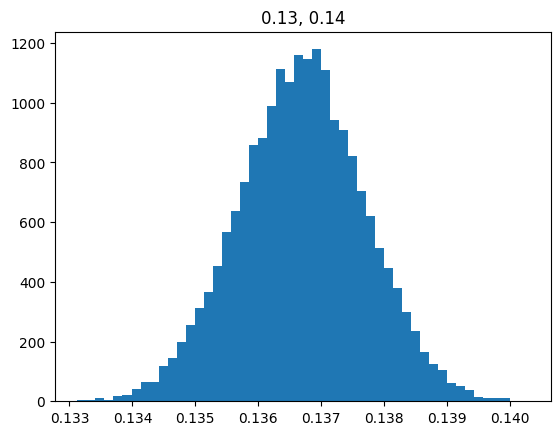

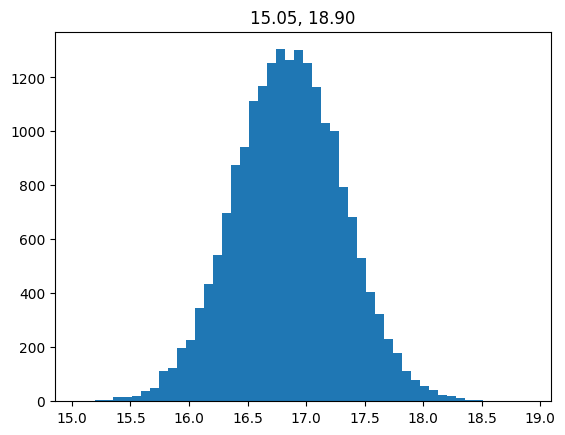

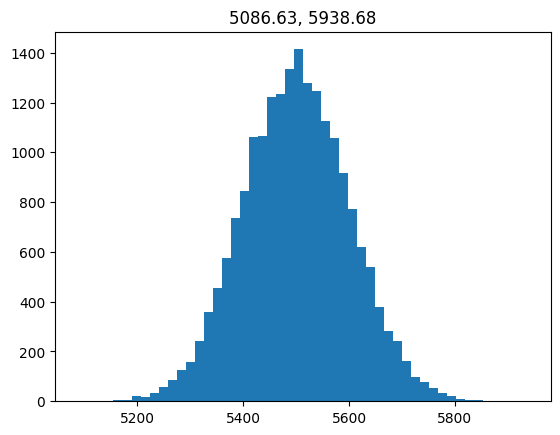

In [8]:
for _ii in range(DIM_THETA):
    zzz = zzparams[:, _ii]
    plt.figure()
    plt.hist(zzz, bins=50)
    plt.title(f'{zzz.min():.2f}, {zzz.max():.2f}')

In [9]:
type(dataset), len(dataset), dataset[0]

(list, 20000, Data(x=[5457, 2], y=[1, 3]))

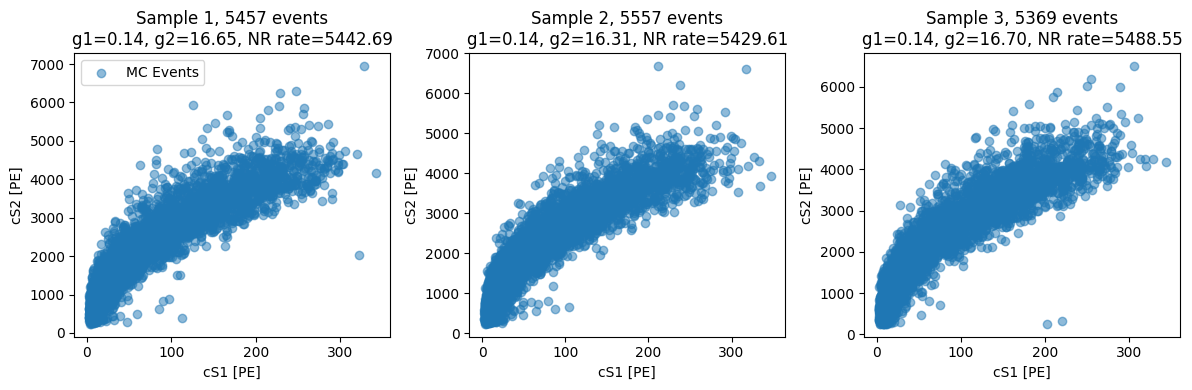

In [10]:
# Plot the first 3 samples from the dataset to visualize the events and their parameters
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    data_sample = dataset[i]
    x_pts = data_sample.x.numpy()
    theta_val = data_sample.y.numpy().flatten()

    axes[i].scatter(x_pts[:, 0], x_pts[:, 1], alpha=0.5, label='MC Events')
    axes[i].set_xlabel('cS1 [PE]')
    axes[i].set_ylabel('cS2 [PE]')

    #axes[i].set_xlim(-5, 5)
    #axes[i].set_ylim(-5, 5)
    axes[i].set_title(f'Sample {i+1}, {(len(x_pts))} events\ng1={theta_val[0]:.2f}, g2={theta_val[1]:.2f}, NR rate={theta_val[2]:.2f}')
    if i == 0:
        axes[i].legend()
plt.tight_layout()
plt.show()

## Data loaders

In [11]:
# Define custom dataset and dataloaders

# PyTorch Dataset wrapper for our generated point sets
class GraphData(data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


graph_dataset = GraphData(dataset)
# Use PyTorch Geometric's Collater to handle batching of variable-size sets
collater = Collater(dataset=graph_dataset, follow_batch='y')


def collate_fn(batch):
    batch = collater(batch)
    return batch, batch.y


# Define train/validation split indices
validation_fraction = 0.1
n_train = int((1 - validation_fraction) * len(graph_dataset))
permuted_idx = np.random.permutation(len(graph_dataset))
idx_train = permuted_idx[:n_train]
idx_val = permuted_idx[n_train:]

# Create PyTorch DataLoaders for training and validation
train_loader = data.DataLoader(
    graph_dataset, batch_size=32, collate_fn=collate_fn,
    sampler=data.SubsetRandomSampler(idx_train), drop_last=True
)
val_loader = data.DataLoader(
    graph_dataset, batch_size=32, collate_fn=collate_fn,
    sampler=data.SubsetRandomSampler(idx_val)
)

# Wrap the PyTorch DataLoaders in an ltu-ili TorchLoader
loader = TorchLoader(train_loader, val_loader)

In [12]:
# Design a simple Deep Set embedder

class DeepSet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # Node MLP applied independently to each point/node
        self.node_mlp = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )
        # Global MLP applied to the aggregated global features
        self.global_mlp = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels), # cause pooling max and mean, so 2x hidden_channels
            nn.ReLU(),
            nn.Linear(hidden_channels, out_channels)
        )

    def forward(self, x):
        node_features, batch = x.x, x.batch

        # Apply node-wise transformation
        node_embed = self.node_mlp(node_features)

        # Pool features globally using both mean and max to ensure permutation invariance
        mean_pool = global_mean_pool(node_embed, batch)
        max_pool = global_max_pool(node_embed, batch)
        # Concatenate pooled features and apply global transformation
        global_embed = torch.cat([mean_pool, max_pool], dim=1)
        return self.global_mlp(global_embed)

embedding = DeepSet(in_channels=DIM_DATA, hidden_channels=32, out_channels=8)

In [13]:
embedding

DeepSet(
  (node_mlp): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
  )
  (global_mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=8, bias=True)
  )
)

In [14]:
# Living lyfe dangerously, define a uniform prior over the parameter space
low_bounds = [0.1, 15, 4000]
high_bounds = [0.2, 20, 7000]

prior = ili.utils.Uniform(
    low=low_bounds,
    high=high_bounds,
    device=device
)

# Define Neural Density Estimators (NDEs) - here using Neural Spline Flows (NSF)
nets = [
    ili.utils.load_nde_lampe(
        model='nsf', hidden_features=32, num_transforms=3,
        # Pass the custom Deep Set embedding network to compress the data
        embedding_net=embedding, x_normalize=False, device=device
    )
]

# Specify training hyperparameters
train_args = {
    'training_batch_size': 32,
    'learning_rate': 1e-4,
    'stop_after_epochs': 20
}

# Initialize the inference runner with the 'lampe' backend for Neural Posterior Estimation (NPE)
runner = InferenceRunner.load(
    backend='lampe',
    engine='NPE',
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
    proposal=None,
    out_dir=None
)

In [15]:
# Run the inference training process to learn the posterior
posterior_ensemble, summaries = runner(loader=loader)

INFO:root:MODEL INFERENCE CLASS: NPE
INFO:root:Training model 1 / 1.
0 epochs [00:00, ? epochs/s]/home/puehlengt/.local/lib/python3.11/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
182 epochs [1:20:49, 26.64s/ epochs, loss=-0.305, loss_val=0.00273]
INFO:root:It took 4849.189233779907 seconds to train models.


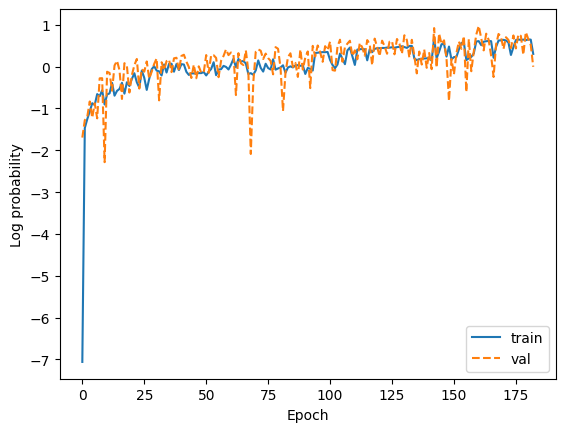

In [16]:

# Plot training and validation log probabilities over epochs
fig, ax = plt.subplots()
for i, m in enumerate(summaries):
    ax.plot(m['training_log_probs'], ls='-', label="train")
    ax.plot(m['validation_log_probs'], ls='--', label="val")
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend()

In [17]:
# Select a single validation sample to evaluate
ind = 3
val_idx = idx_val[ind]
x_ = graph_dataset[val_idx] # torch_geometric.data.data.Data object lol
# Get the true parameter values
y_ = x_.y[0].numpy()

torch.manual_seed(1234)
# Sample from the trained posterior ensemble
samples = posterior_ensemble.sample((1000,), x_)
# Evaluate the log probability of the samples
log_prob = posterior_ensemble.log_prob(samples, x_)

samples = samples.cpu().numpy()
log_prob = log_prob.cpu().numpy()

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 31465.85it/s]


In [18]:
type(samples), samples.shape, log_prob.shape, samples[0]

(numpy.ndarray,
 (1000, 3),
 (1000,),
 array([1.3487940e-01, 1.6699186e+01, 5.4400229e+03], dtype=float32))

Text(0, 0.5, 'cS2 [PE]')

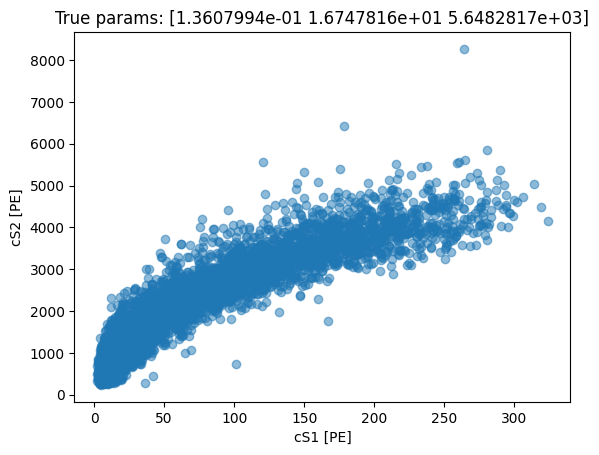

In [19]:
test = x_.x.cpu().numpy()
plt.scatter(test[:, 0], test[:, 1], alpha=0.5, label='MC Events')
plt.title(f'True params: {y_}')
plt.xlabel('cS1 [PE]')
plt.ylabel('cS2 [PE]')

In [20]:
dim_theta = DIM_THETA

In [21]:
type(samples), samples.shape

(numpy.ndarray, (1000, 3))

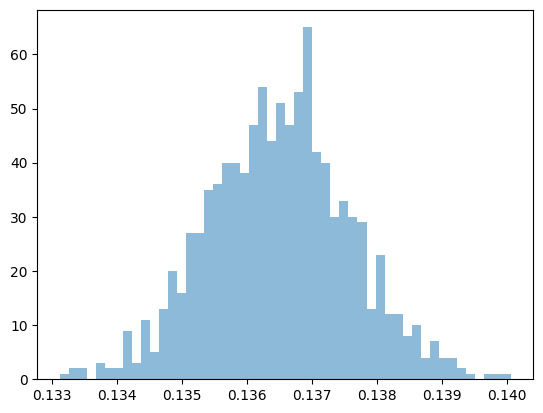

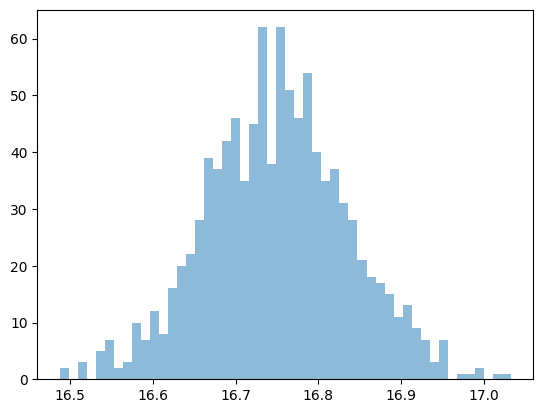

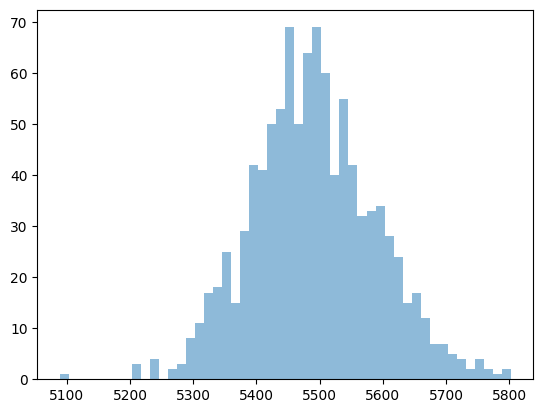

In [22]:
for _ii in range(DIM_THETA):
    plt.figure()
    plt.hist(samples[:, _ii], bins=50, alpha=0.5, label=f'sample dim {_ii}')


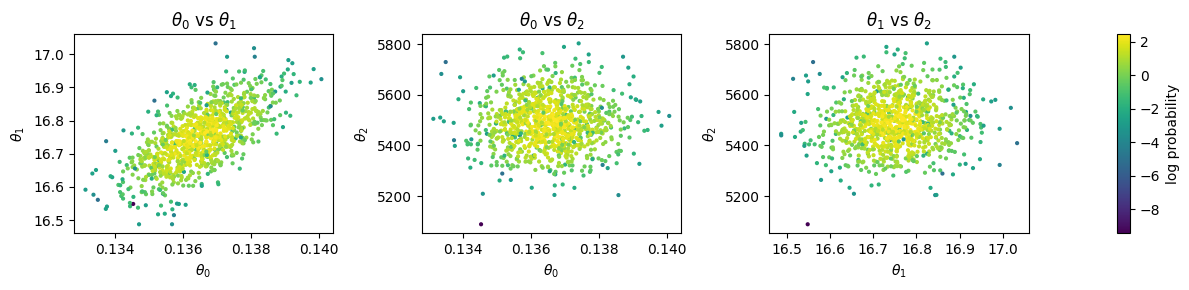

In [23]:
from itertools import combinations

# Visualize the posterior samples compared to the true value for 3D
dim_theta = DIM_THETA
n_combinations = dim_theta * (dim_theta - 1) // 2  # 3 choose 2 = 3

# Create subplots: one for each pair combination + one colorbar
fig, axs = plt.subplots(1, n_combinations + 1, 
                        figsize=(3 * (n_combinations + 1), 3),
                        gridspec_kw={'width_ratios': [1] * n_combinations + [0.05]})

# Get all pair combinations of parameters
param_pairs = list(combinations(range(dim_theta), 2))
param_names = [r'$\theta_0$', r'$\theta_1$', r'$\theta_2$']

# Plot each combination
for idx, (i, j) in enumerate(param_pairs):
    # Scatter plot of samples
    im = axs[idx].scatter(samples[:, i], samples[:, j],
                          c=log_prob, s=4, cmap='viridis')
    axs[idx].set_xlabel(param_names[i])
    axs[idx].set_ylabel(param_names[j])
    axs[idx].set_title(f'{param_names[i]} vs {param_names[j]}')
    
    # Optional: plot the true value if you have it
    # true_values = [true_theta0, true_theta1, true_theta2]  # define your true values
    # axs[idx].plot(true_values[i], true_values[j], 'r+', markersize=10, label='true')
    # axs[idx].legend()

# Add colorbar to the last subplot
plt.colorbar(im, label='log probability', cax=axs[-1])

plt.tight_layout()
plt.show()


INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 55558.11it/s]


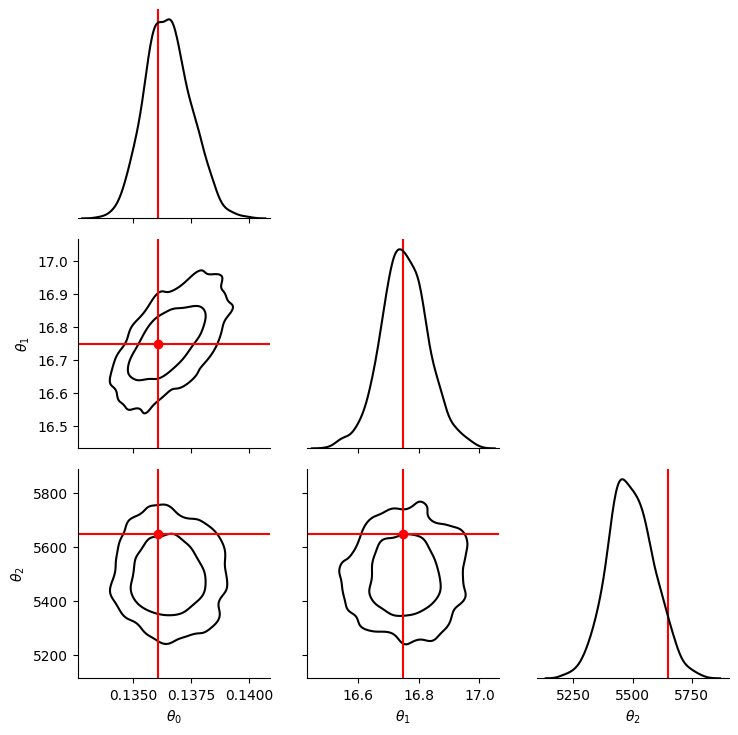

In [24]:

metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=[f'$\\theta_{i}$' for i in range(dim_theta)]
)
fig = metric(
    posterior=posterior_ensemble,
    x_obs=x_, theta_fid=y_
)

In [25]:
thetas = params

100%|██████████| 100/100 [03:59<00:00,  2.40s/it]


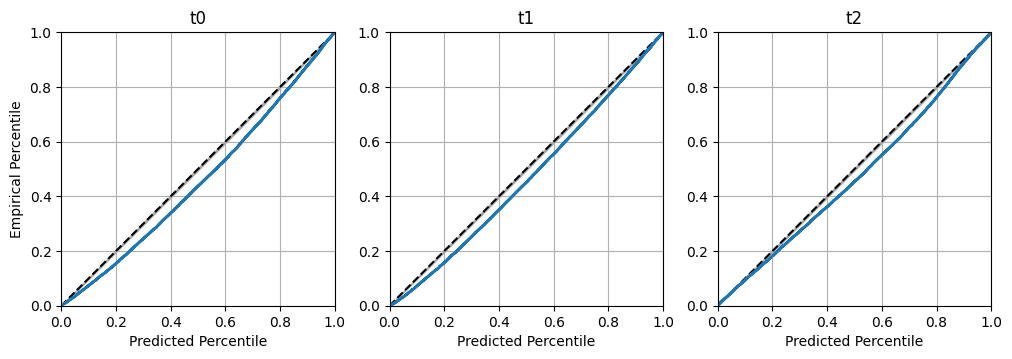

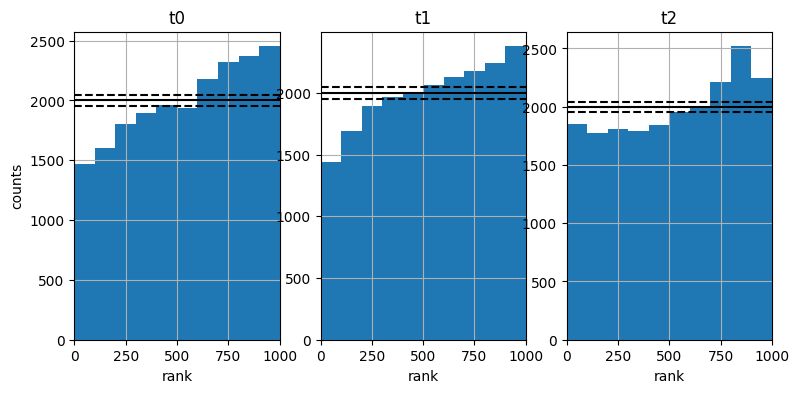

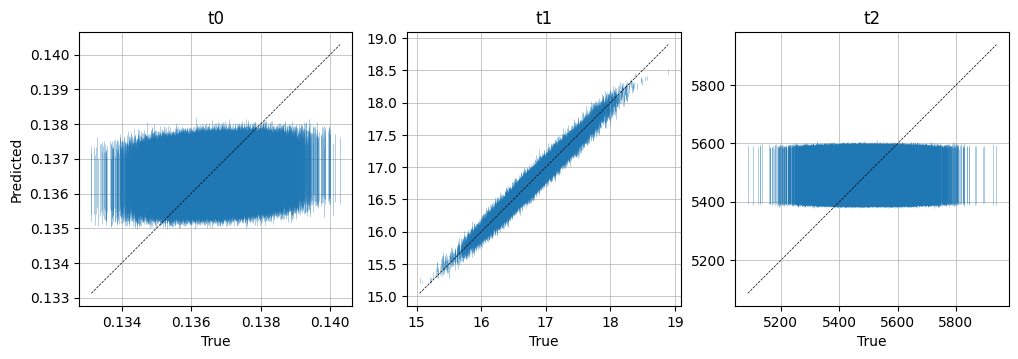

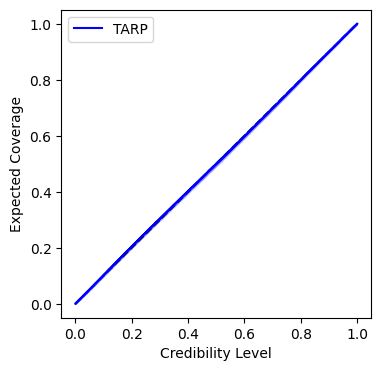

In [26]:
# PosteriorCoverage
metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    out_dir=None, labels=[f't{i}' for i in range(dim_theta)],
    plot_list=["coverage", "histogram", "predictions", "tarp"],
    save_samples=True
)
fig = metric(
    posterior=posterior_ensemble,
    x=graph_dataset, theta=thetas
)